# Enhancing Transaction Monitoring with Machine Learning

Problem Statement : We need to create a better system to monitor customer transactions for potential money laundering in a small bank with 1000 customers. Right now, the bank uses a simple rule: If someone’s monthly non-salary transactions exceed 9000, they get flagged for review and are further investigated, which is a reliable data, but the bank have no identified a way for transactions below 9000.

The task is to design a smarter machine learning model that can identify suspicious activities more accurately, irrespective of the rule.

In [351]:
# Importing all the packages


# Util Packages
import pandas as pd
from sklearn.preprocessing import OneHotEncoder
from os import times_result
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

# Plotting packages
import seaborn as sns
import matplotlib.pyplot as plt


# ML Model Packages
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import IsolationForest



In [352]:
# Importing the data files

df_transactions = pd.read_csv('/content/df_transactions.csv')
df_kyc = pd.read_csv('/content/df_kyc.csv')
df_labels = pd.read_csv('/content/df_label.csv')

## Splitting the DataSet into Trusted and NonTrusted Data

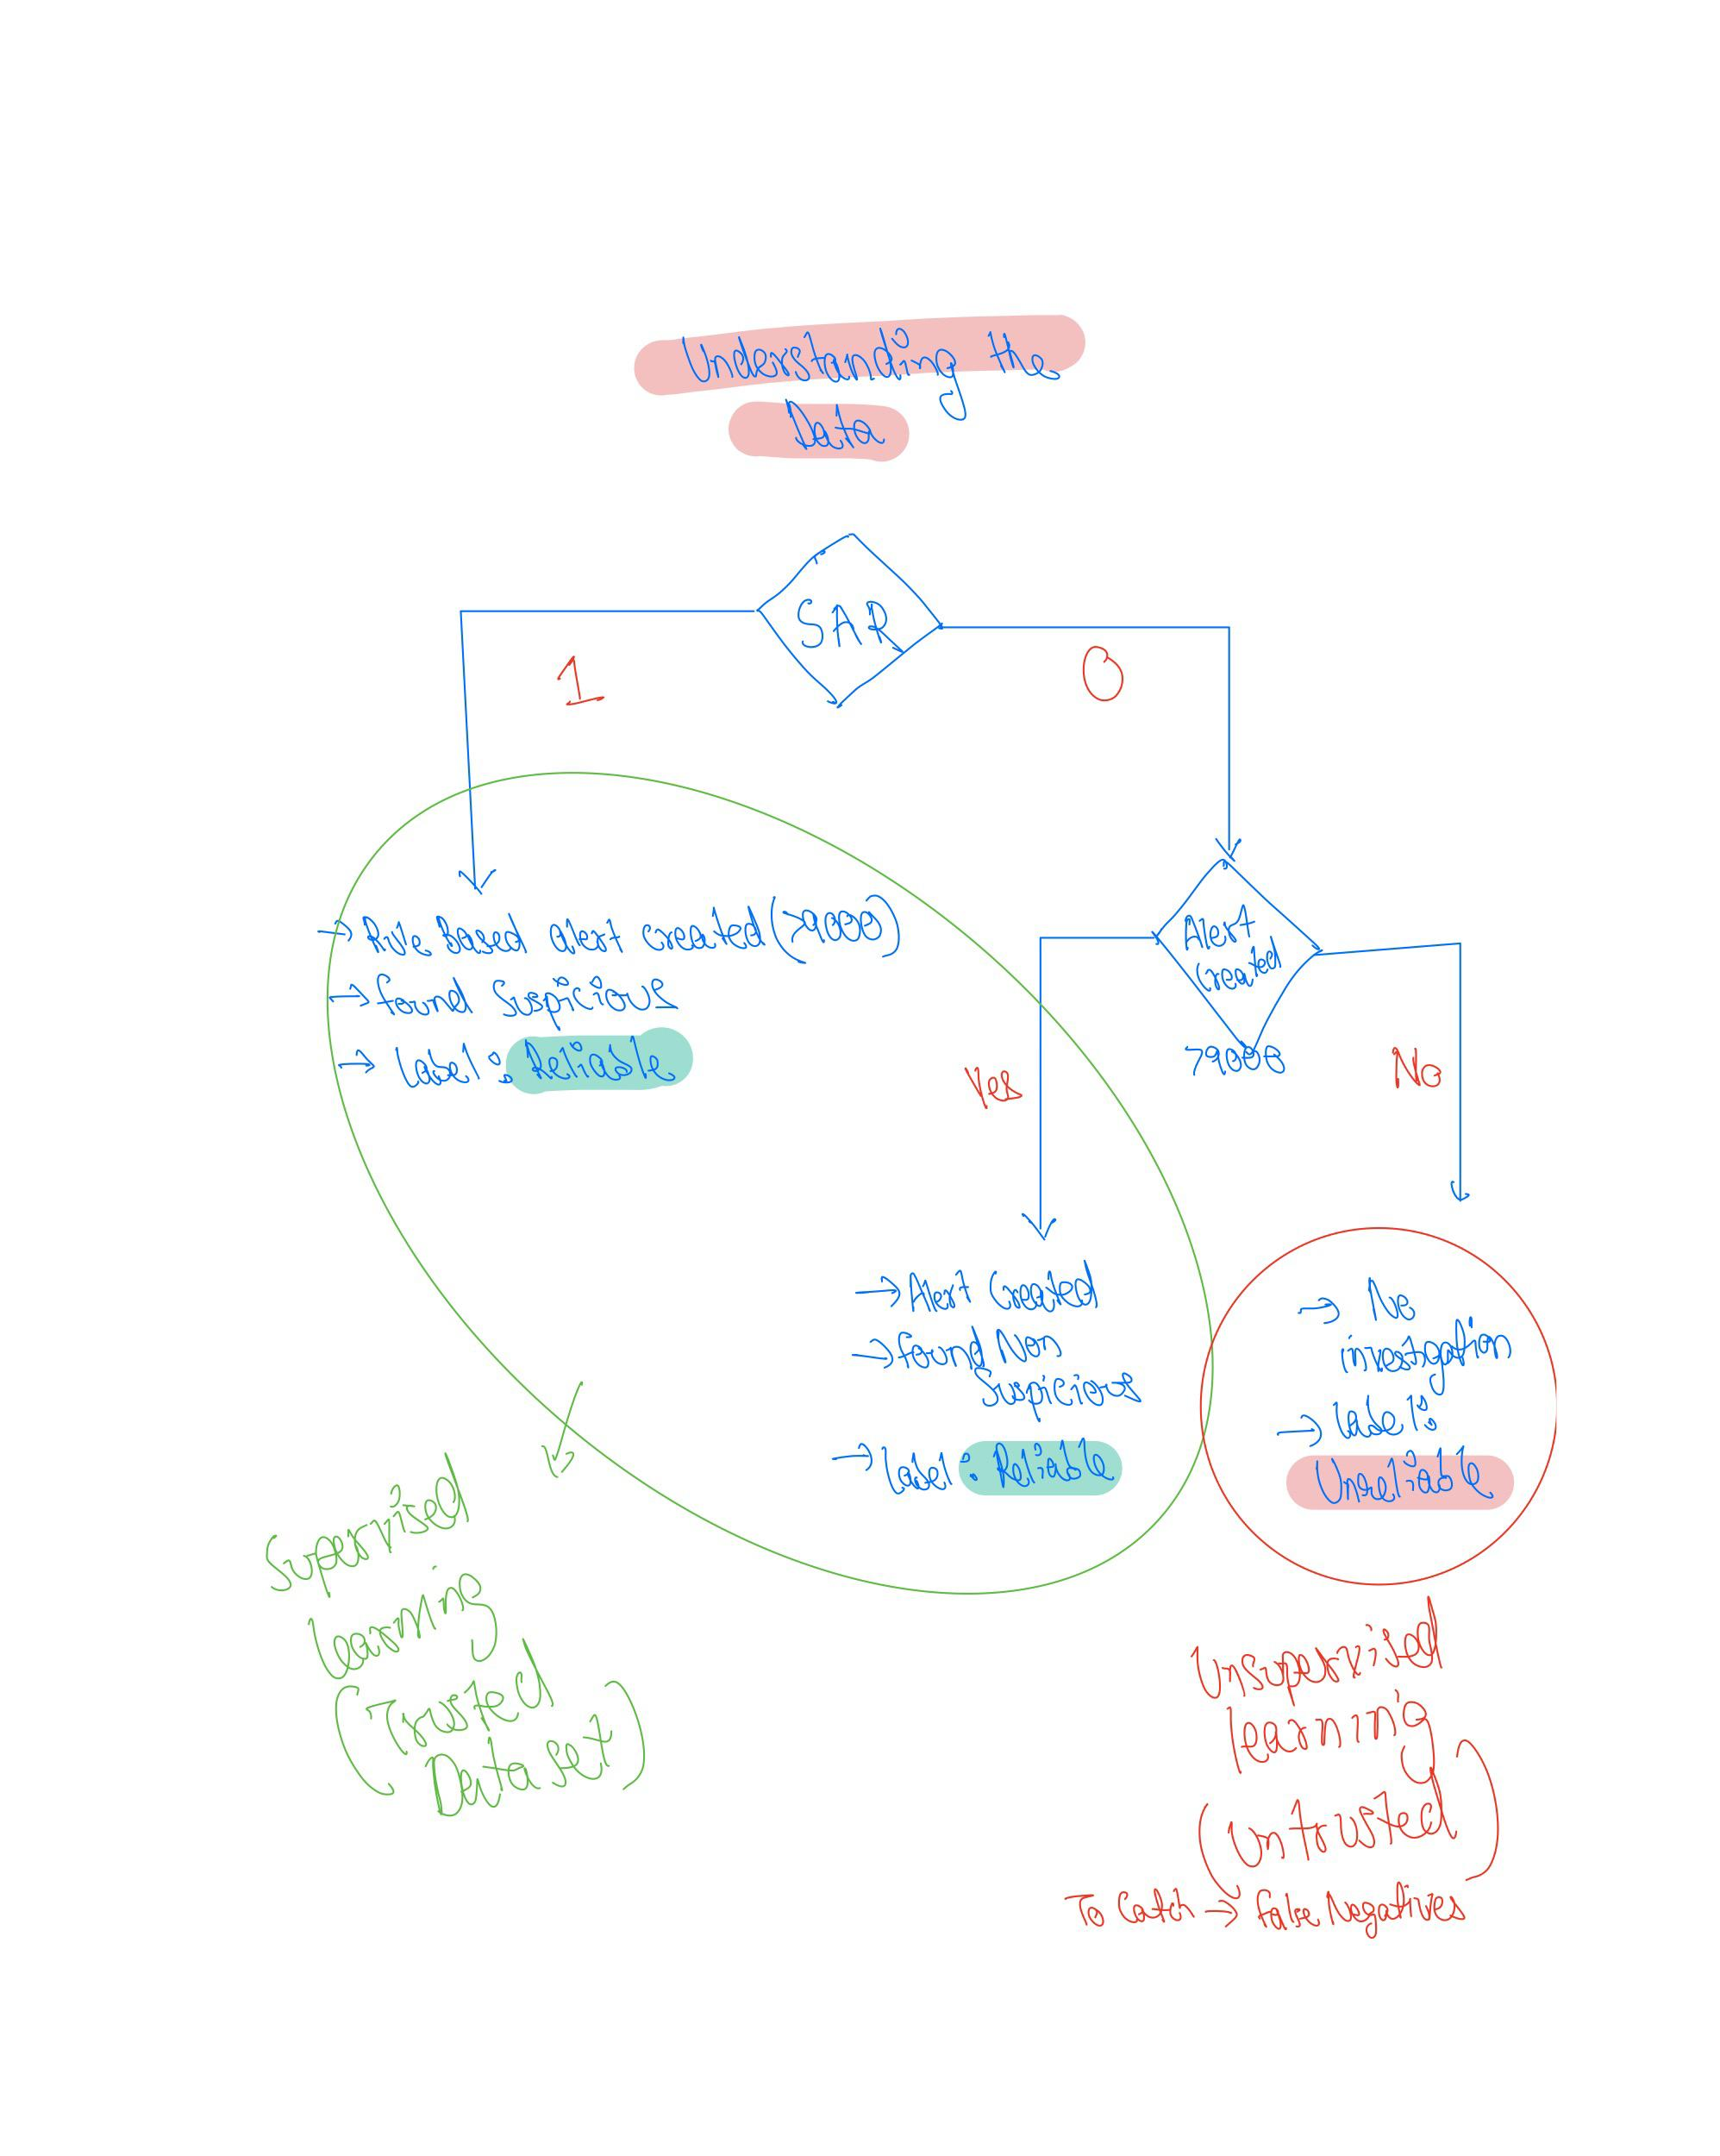

In [353]:
# Merge transactions with labels
df_trans_labels_merged = pd.merge(df_transactions, df_labels, on=["Customer_ID", "Month"], how="inner")

# Exclude salary transactions as per the requirement given in the instructionss
df_trans_labels_merged = df_trans_labels_merged[df_trans_labels_merged["Transaction_Type"] != "Salary"]

# Create a blank column for the number of transactions (as per the research, this could be a factor)
df_trans_labels_merged["No_Of_Monthly_Transactions"] = None

# Aggregate monthly transaction sums, using absolute values because there are withdrawals and deposits.
df_agg = df_trans_labels_merged.groupby(["Customer_ID", "Month"]).agg(
    {
        "Transaction_Value": lambda x: x.abs().sum(),                    # Sum of transaction values
        "SAR": "max",                                                   # Maximum SAR label
        "Transaction_Type": lambda x: x.mode()[0] if not x.mode().empty else None,  # Most frequent Transaction_Type
        "No_Of_Monthly_Transactions": lambda x: len(x)
    }
).reset_index()

df_agg_kyc = pd.merge(df_agg, df_kyc, on="Customer_ID", how="inner")


# Splitting datasets
# Trusted dataset: Customers flagged by the rule (Transaction_Value > 9000).
trusted_data = df_agg_kyc[(df_agg_kyc["Transaction_Value"] > 9000)]

# Untrusted dataset: customers not flagged (Transaction_Value <= 9000) and labeled 0
# Not necessariy for the and condition, because even without that, all SAR for Transaction <= 9000 are 0.
untrusted_data = df_agg_kyc[(df_agg_kyc["Transaction_Value"] <= 9000) & (df_agg_kyc["SAR"] == 0)]

<ipython-input-353-58ba874b2caf>:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_trans_labels_merged["No_Of_Monthly_Transactions"] = None


## TrustedData for Supervised Learning

### Exploratory Data Analysis

#### Sex vs SAR

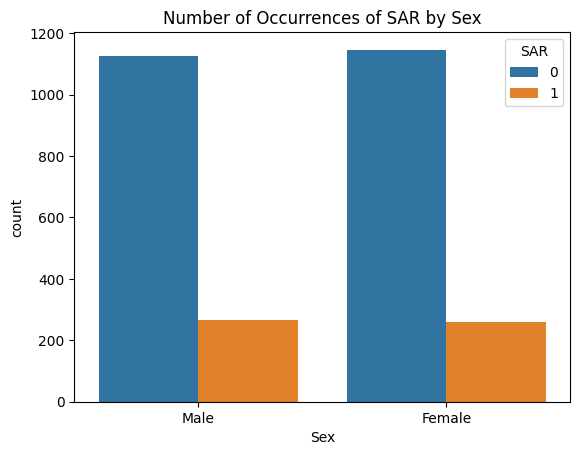

In [354]:
sns.countplot(x='Sex', hue='SAR', data=trusted_data)
plt.title('Number of Occurrences of SAR by Sex')
plt.show()

Conclusion : Sex might not strongly correlate with suspicious activity

#### Vulnerable Area vs SAR

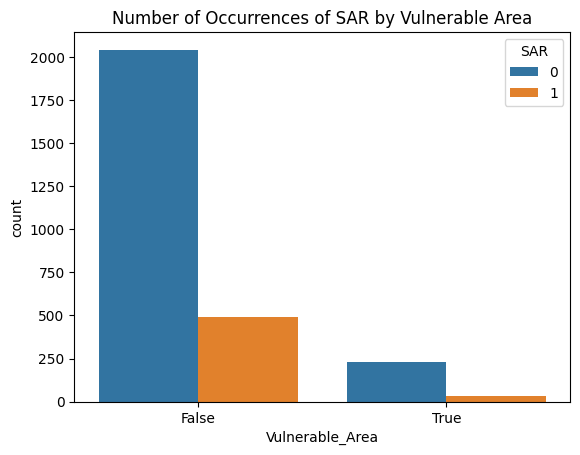

In [355]:
sns.countplot(x='Vulnerable_Area', hue='SAR', data=trusted_data)
plt.title('Number of Occurrences of SAR by Vulnerable Area')
plt.show()

#### Age vs SAR

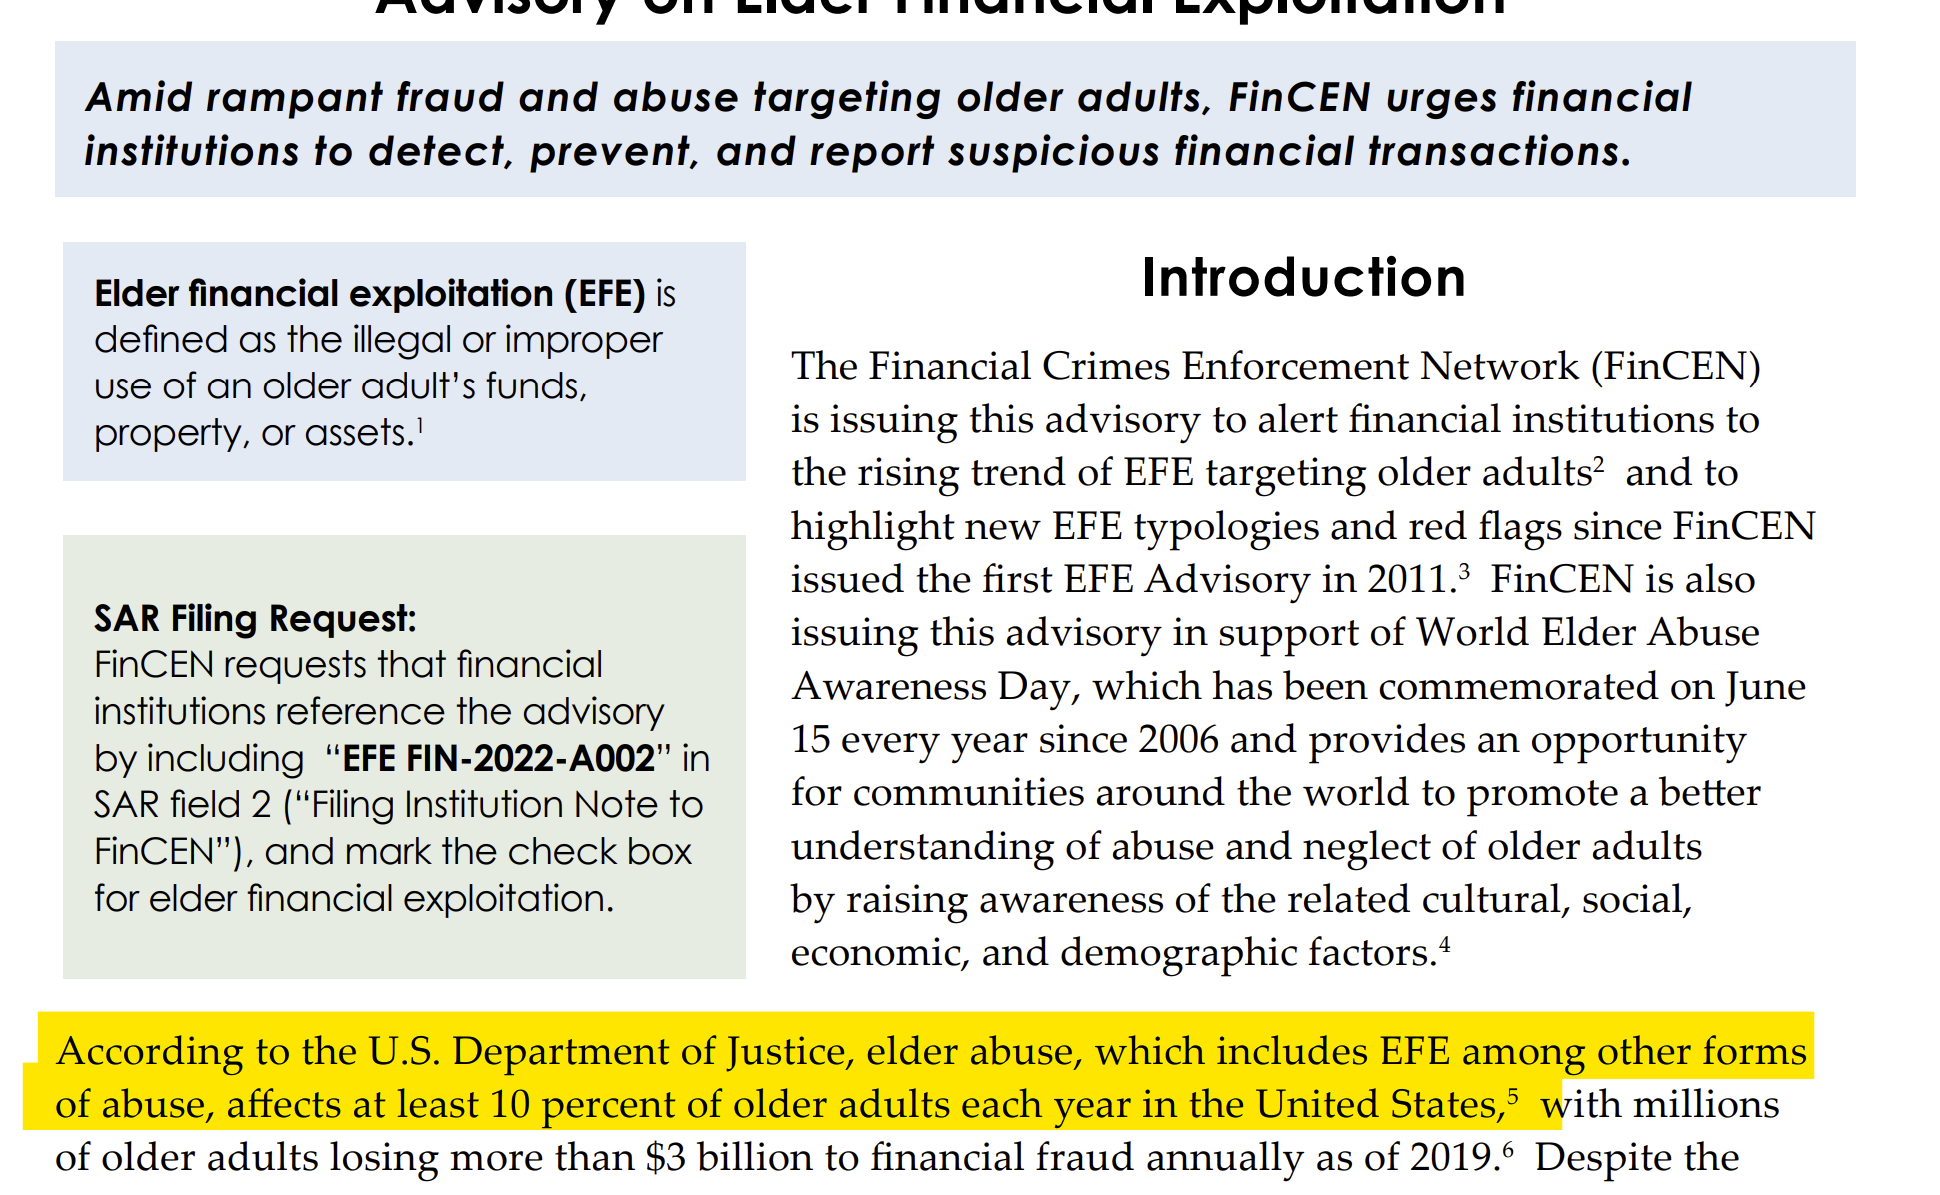

Source : https://www.fincen.gov/sites/default/files/advisory/2022-06-15/FinCEN%20Advisory%20Elder%20Financial%20Exploitation%20FINAL%20508.pdf?utm_source=chatgpt.com

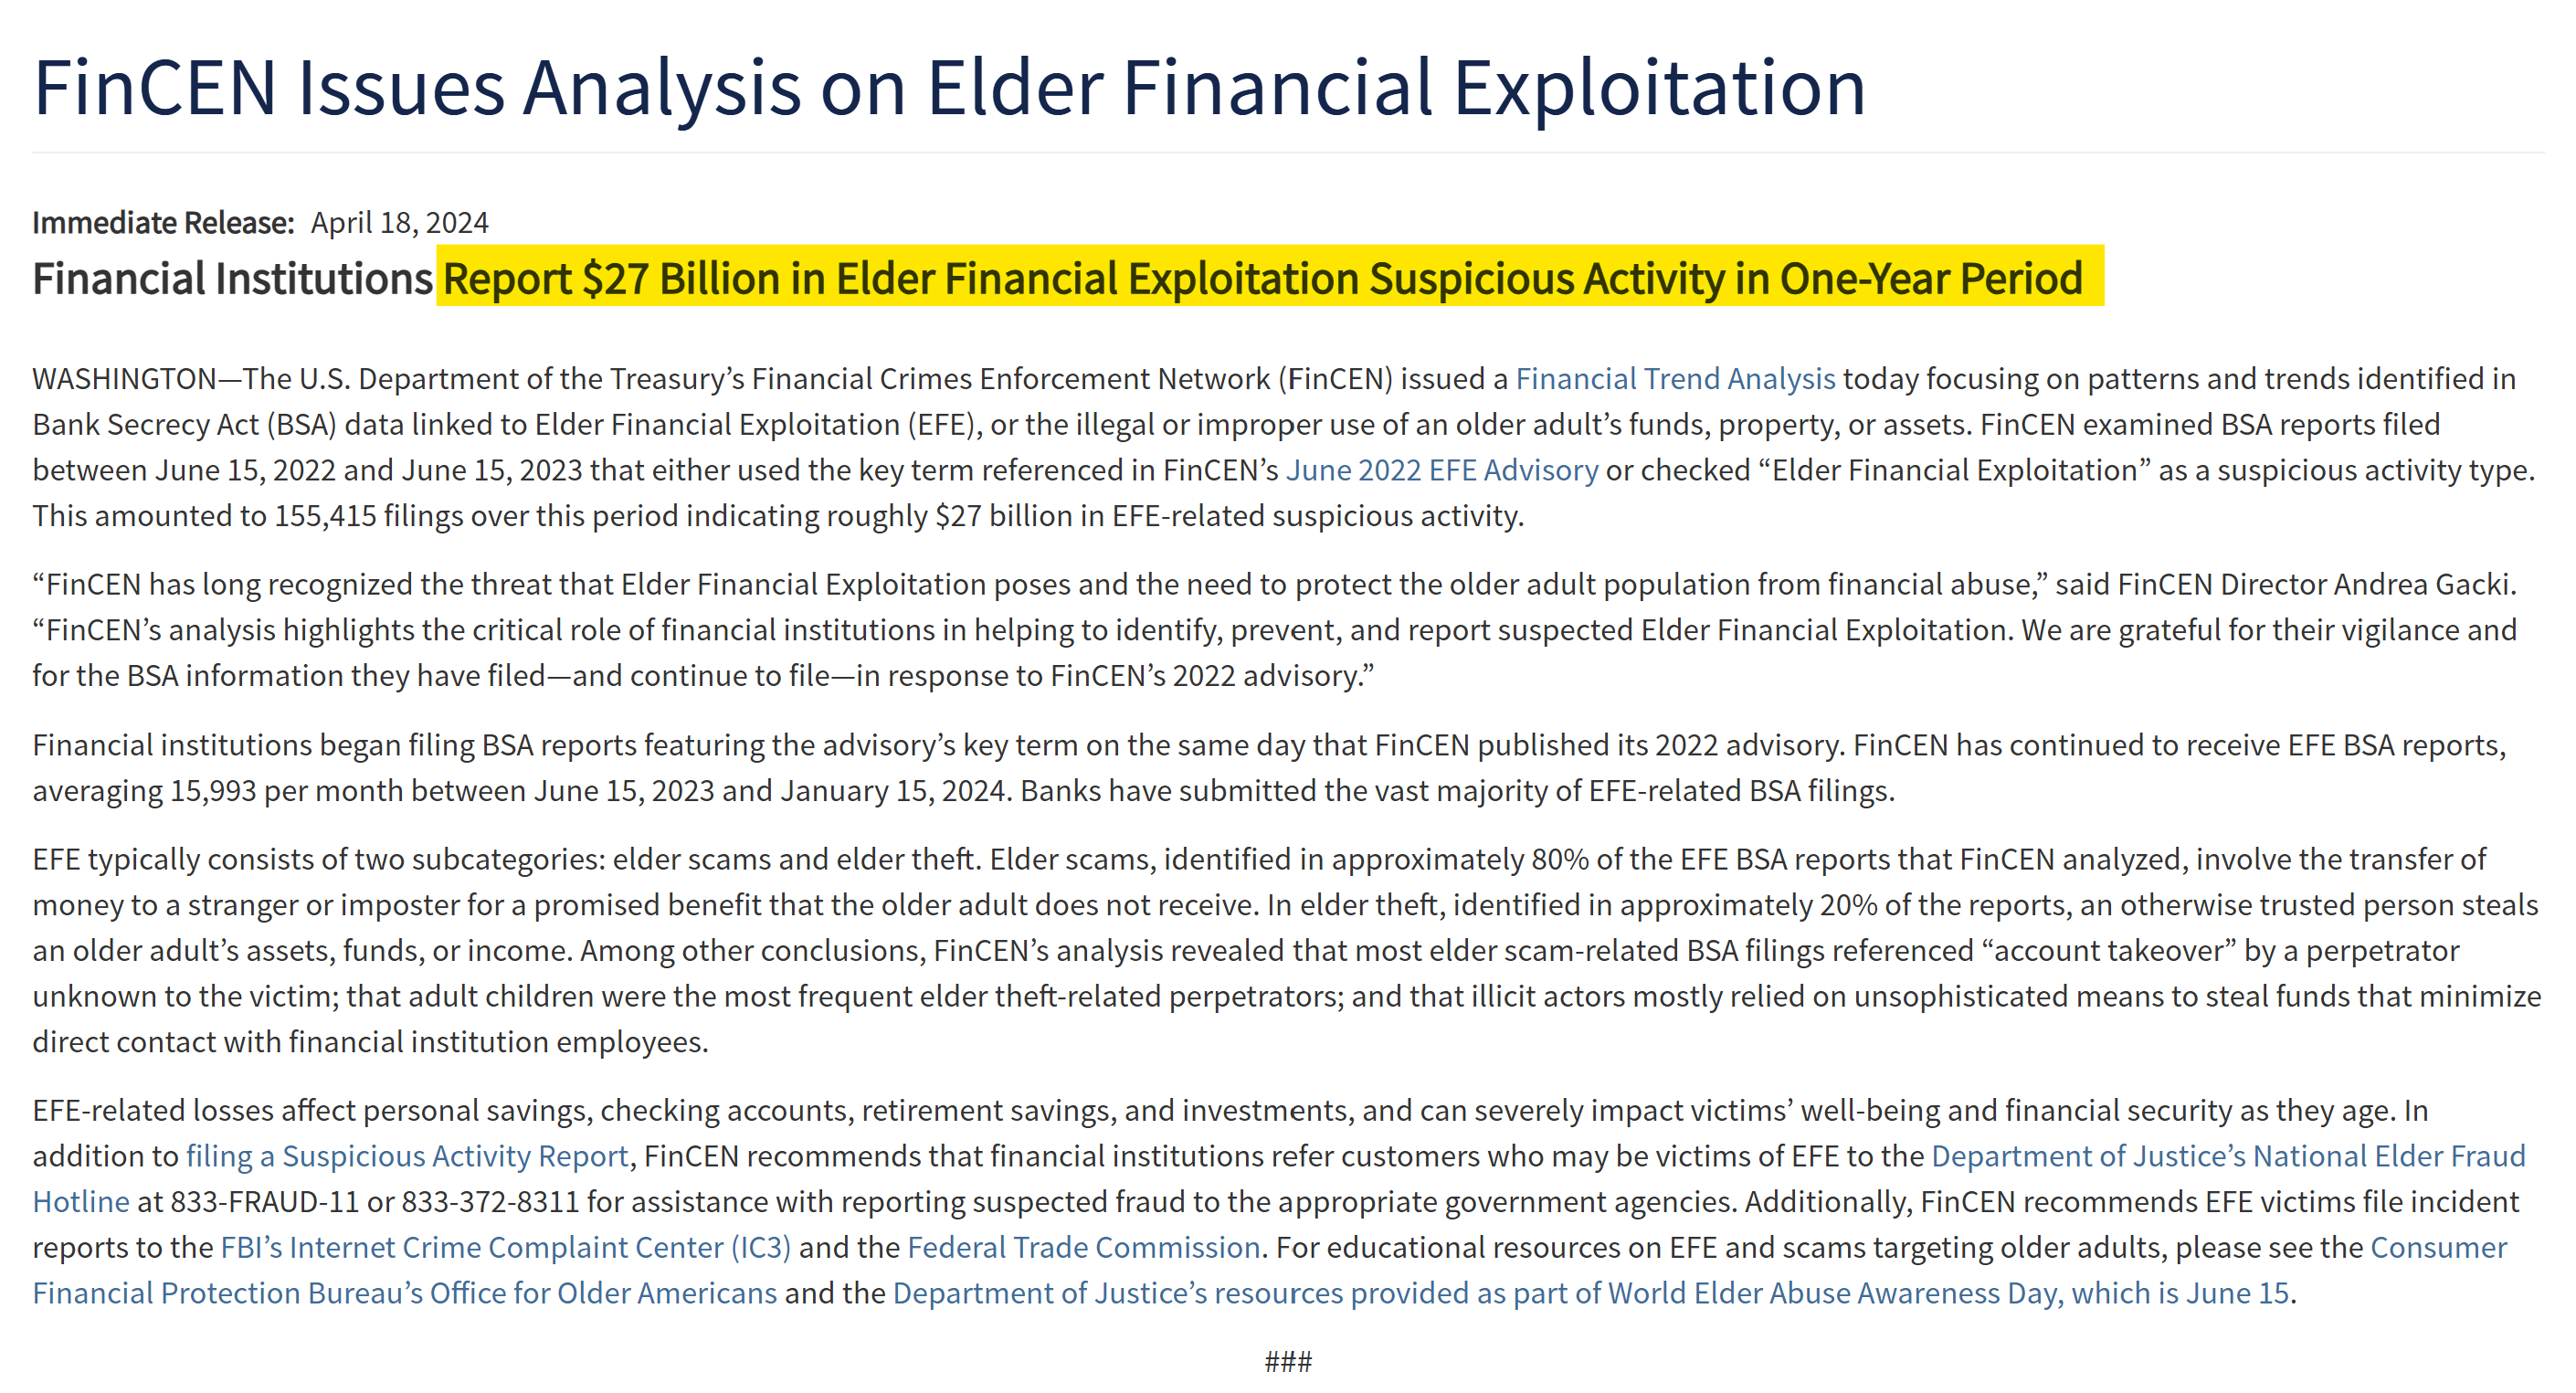

Source : https://www.fincen.gov/news/news-releases/fincen-issues-analysis-elder-financial-exploitation?utm_source=chatgpt.com

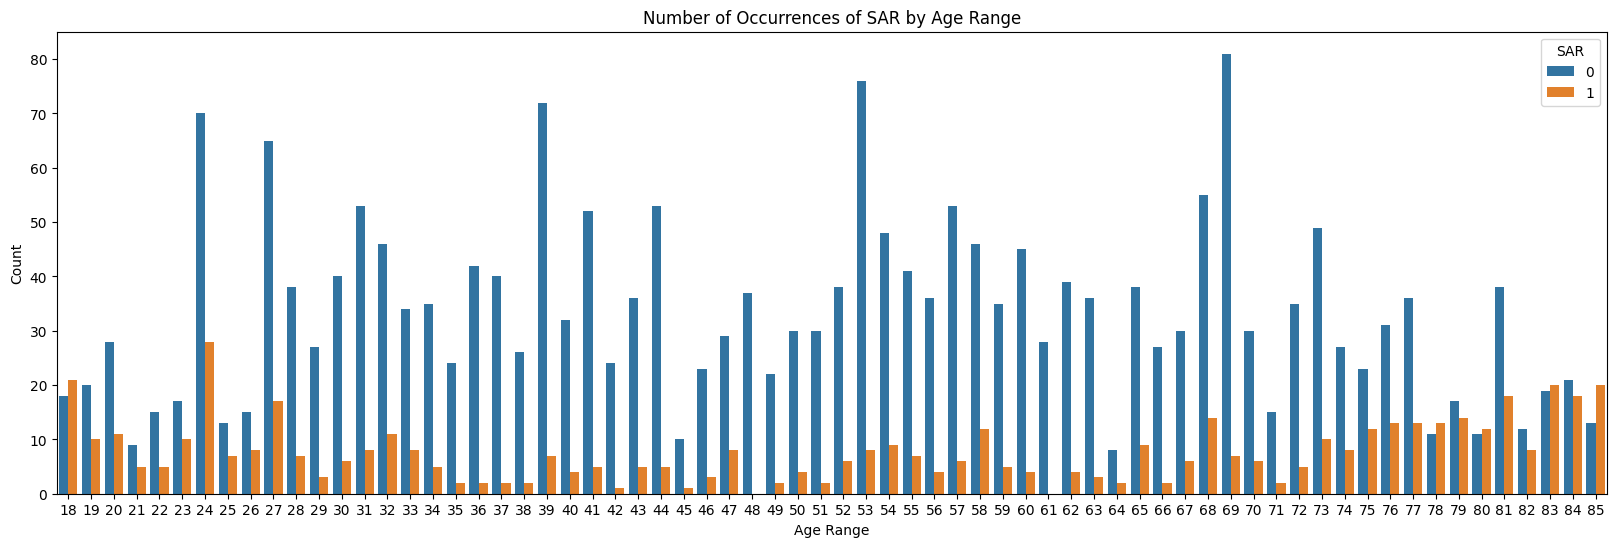

In [356]:
plt.figure(figsize=(20, 6))
sns.countplot(x='Age', hue='SAR', data=trusted_data)
plt.title('Number of Occurrences of SAR by Age Range')
plt.xlabel('Age Range')
plt.ylabel('Count')
plt.show()

Specific age ranges (e.g., around 23–25, 74+) show relatively higher counts of SAR = 1 compared to other age groups.

Younger individuals may show higher activity overall, with a small percentage flagged as suspicious.
Older individuals might have a smaller sample size but higher relative SAR counts.

In [357]:
# Calculate SAR count by age group
sar_counts_by_age = trusted_data.groupby(["Age", "SAR"]).size().unstack(fill_value=0)
print(sar_counts_by_age)

sar_counts_by_age["SAR_1_Percentage"] = (sar_counts_by_age[1] / (sar_counts_by_age[0] + sar_counts_by_age[1])) * 100

print(sar_counts_by_age[["SAR_1_Percentage"]])


SAR   0   1
Age        
18   18  21
19   20  10
20   28  11
21    9   5
22   15   5
..   ..  ..
81   38  18
82   12   8
83   19  20
84   21  18
85   13  20

[68 rows x 2 columns]
SAR  SAR_1_Percentage
Age                  
18          53.846154
19          33.333333
20          28.205128
21          35.714286
22          25.000000
..                ...
81          32.142857
82          40.000000
83          51.282051
84          46.153846
85          60.606061

[68 rows x 1 columns]


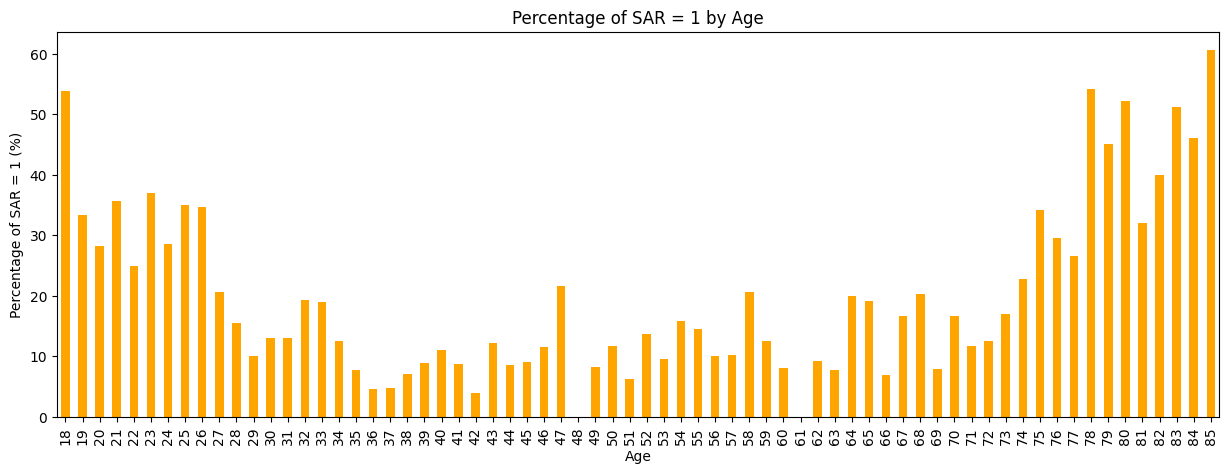

In [358]:
sar_counts_by_age["SAR_1_Percentage"].plot(kind="bar", figsize=(15, 5), color="orange")
plt.title("Percentage of SAR = 1 by Age")
plt.xlabel("Age")
plt.ylabel("Percentage of SAR = 1 (%)")
plt.show()


#### Month vs SAR

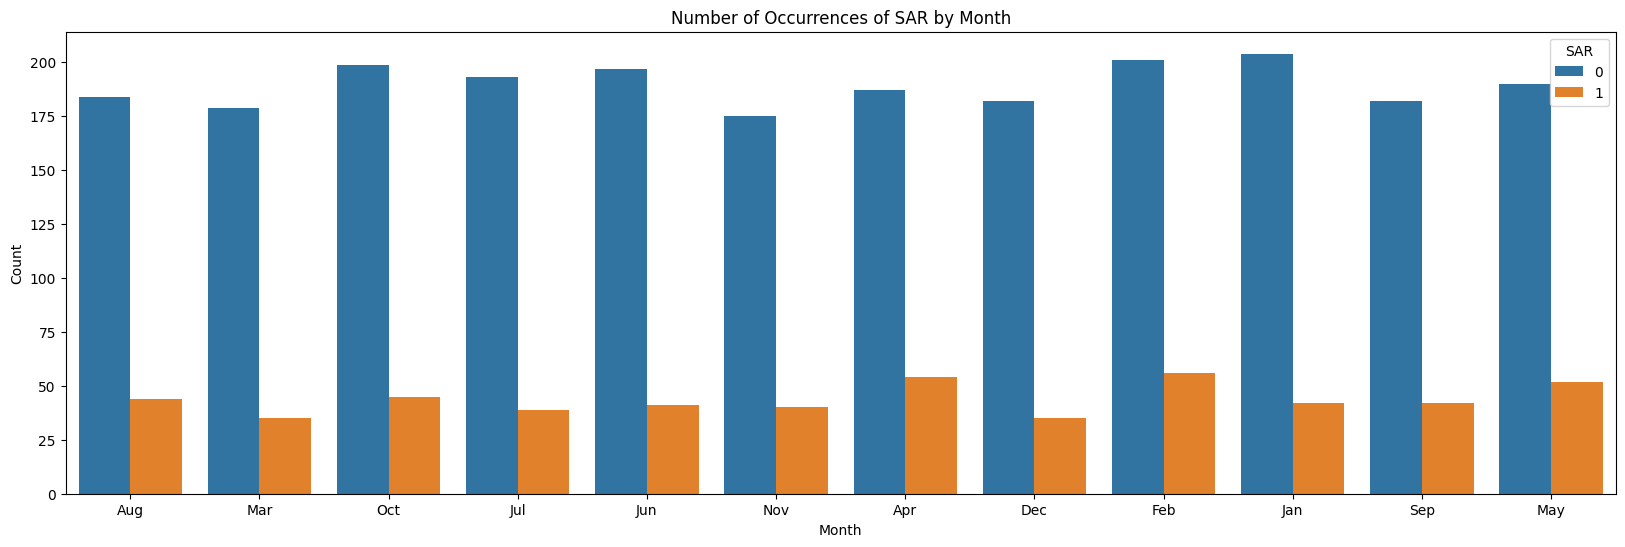

In [359]:
plt.figure(figsize=(20, 6))
sns.countplot(x='Month', hue='SAR', data=trusted_data)
plt.title('Number of Occurrences of SAR by Month')
plt.xlabel('Month')
plt.ylabel('Count')
plt.show()

#### Intention International Payments vs SAR

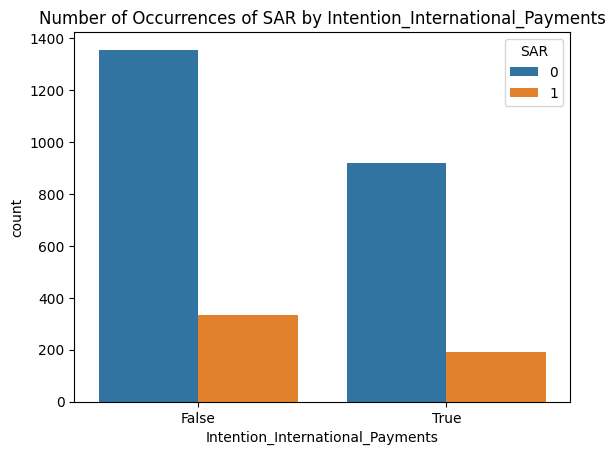

In [360]:
sns.countplot(x='Intention_International_Payments', hue='SAR', data=trusted_data)
plt.title('Number of Occurrences of SAR by Intention_International_Payments')
plt.show()

#### Intention Cash Deposits vs SAR

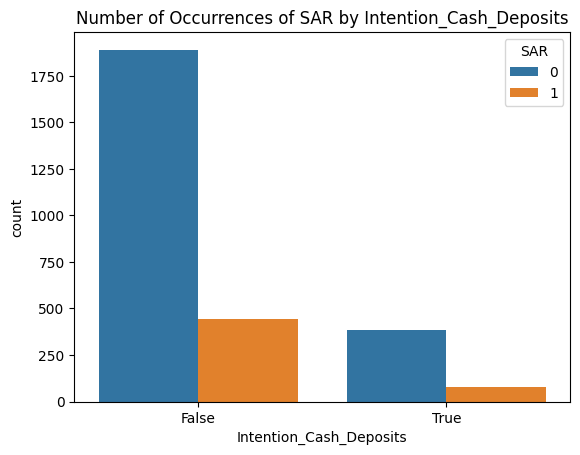

In [361]:
sns.countplot(x='Intention_Cash_Deposits', hue='SAR', data=trusted_data)
plt.title('Number of Occurrences of SAR by Intention_Cash_Deposits')
plt.show()

#### High Risk Transaction vs SAR

<ipython-input-362-6fc6d2390725>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trusted_data['High_Risk_Transaction'] = (trusted_data['High_Risk_Country'] & trusted_data['Vulnerable_Area'])


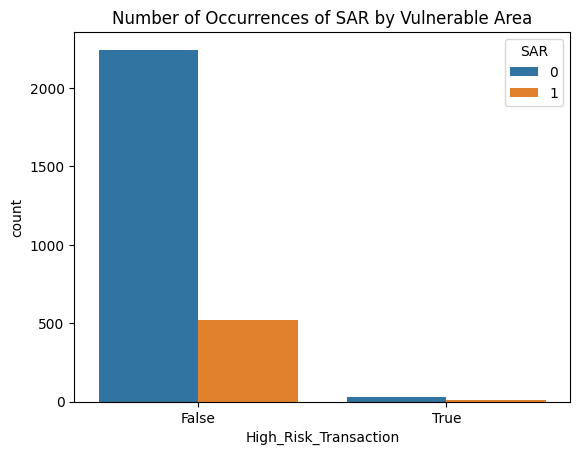

In [362]:
# AND CONDITION
trusted_data['High_Risk_Transaction'] = (trusted_data['High_Risk_Country'] & trusted_data['Vulnerable_Area'])
sns.countplot(x='High_Risk_Transaction', hue='SAR', data=trusted_data)
plt.title('Number of Occurrences of SAR by Vulnerable Area')
plt.show()

<ipython-input-363-e18a0d82b565>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trusted_data['High_Risk_Transaction'] = (trusted_data['High_Risk_Country'] | trusted_data['Vulnerable_Area'])


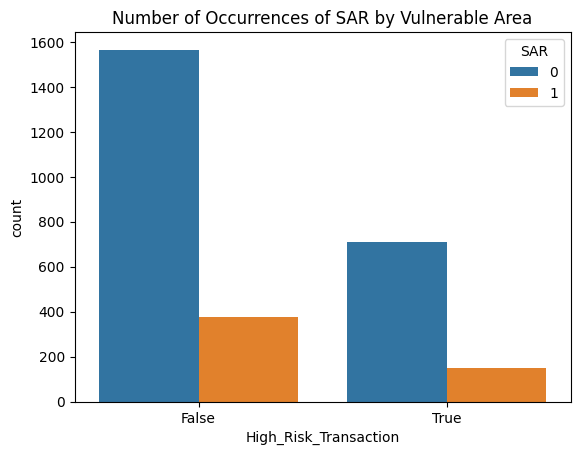

In [363]:
# OR CONDITION
trusted_data['High_Risk_Transaction'] = (trusted_data['High_Risk_Country'] | trusted_data['Vulnerable_Area'])
sns.countplot(x='High_Risk_Transaction', hue='SAR', data=trusted_data)
plt.title('Number of Occurrences of SAR by Vulnerable Area')
plt.show()

#### Number of Monthly Transaction vs SAR

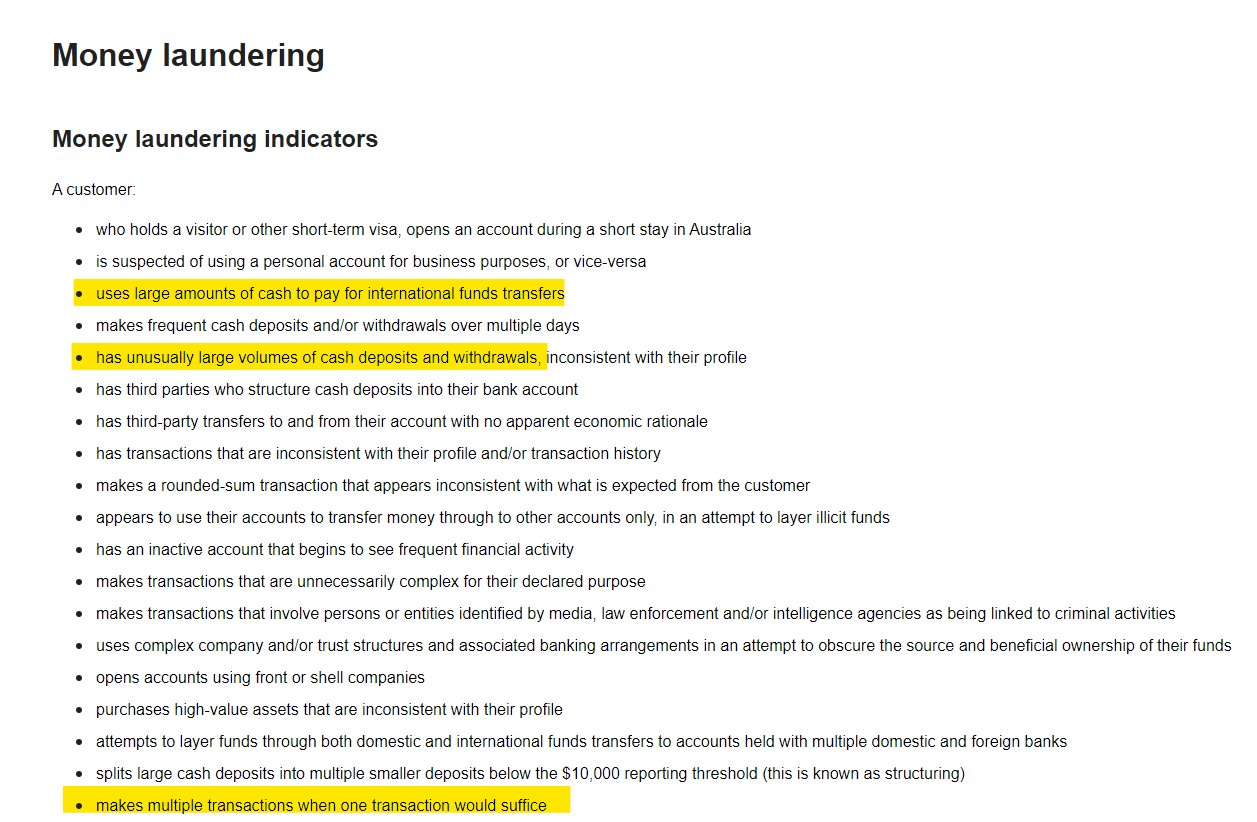

Source :https://www.austrac.gov.au/business/how-comply-guidance-and-resources/guidance-resources/indicators-suspicious-activity-banking-sector-0

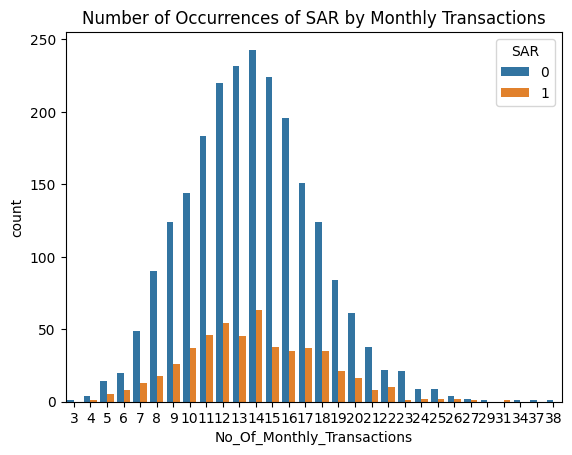

In [364]:
sns.countplot(x='No_Of_Monthly_Transactions', hue='SAR', data=trusted_data)
plt.title('Number of Occurrences of SAR by Monthly Transactions')
plt.show()

In [365]:
# Calculate SAR count by number of monthly transactions
sar_counts_by_monthly_tranactions = trusted_data.groupby(["No_Of_Monthly_Transactions", "SAR"]).size().unstack(fill_value=0)
print(sar_counts_by_monthly_tranactions)

# Add a new column for percentage of SAR = 1
sar_counts_by_monthly_tranactions["Tra_1_Percentage"] = (sar_counts_by_monthly_tranactions[1] / (sar_counts_by_monthly_tranactions[0] + sar_counts_by_monthly_tranactions[1])) * 100

# Display the result
print(sar_counts_by_monthly_tranactions[["Tra_1_Percentage"]])


SAR                           0   1
No_Of_Monthly_Transactions         
3                             1   0
4                             4   1
5                            14   5
6                            20   8
7                            49  13
8                            90  18
9                           124  26
10                          144  37
11                          183  46
12                          220  54
13                          232  45
14                          243  63
15                          224  38
16                          196  35
17                          151  37
18                          124  35
19                           84  21
20                           61  16
21                           38   8
22                           22  10
23                           21   1
24                            9   2
25                            9   2
26                            4   2
27                            2   1
29                          

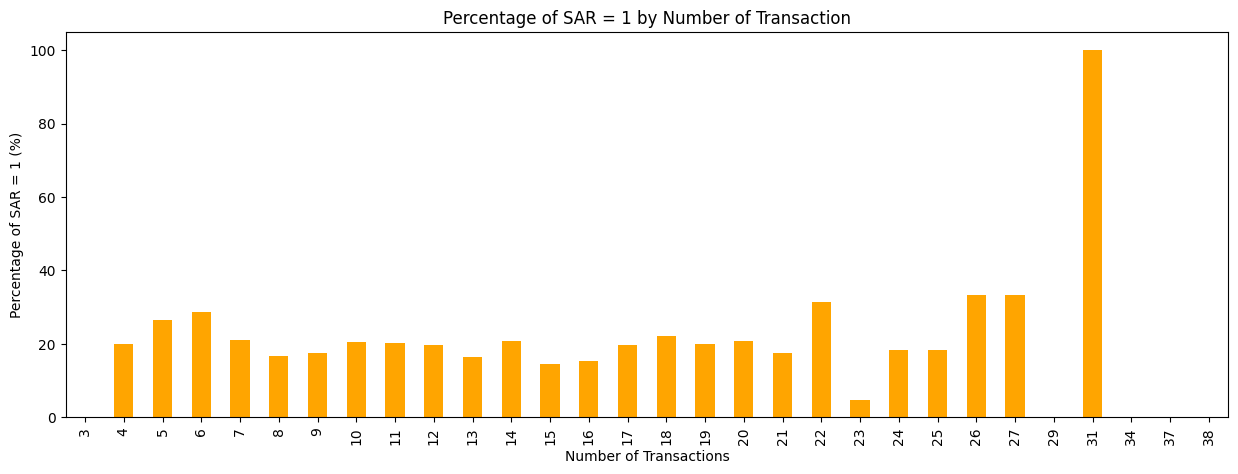

In [366]:
# Plot the percentage of SAR = 1 by monthly transactions
sar_counts_by_monthly_tranactions["Tra_1_Percentage"].plot(kind="bar", figsize=(15, 5), color="orange")
plt.title("Percentage of SAR = 1 by Number of Transaction")
plt.xlabel("Number of Transactions")
plt.ylabel("Percentage of SAR = 1 (%)")
plt.show()


Quite less people make monthly transactions more than 22, but more % are towards SAR triggered

#### Average Value Per Transaction

In [367]:
trusted_data['Average_Value_Per_Transaction'] = trusted_data['Transaction_Value'] / trusted_data['No_Of_Monthly_Transactions']

<ipython-input-367-12b5c24f1065>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trusted_data['Average_Value_Per_Transaction'] = trusted_data['Transaction_Value'] / trusted_data['No_Of_Monthly_Transactions']


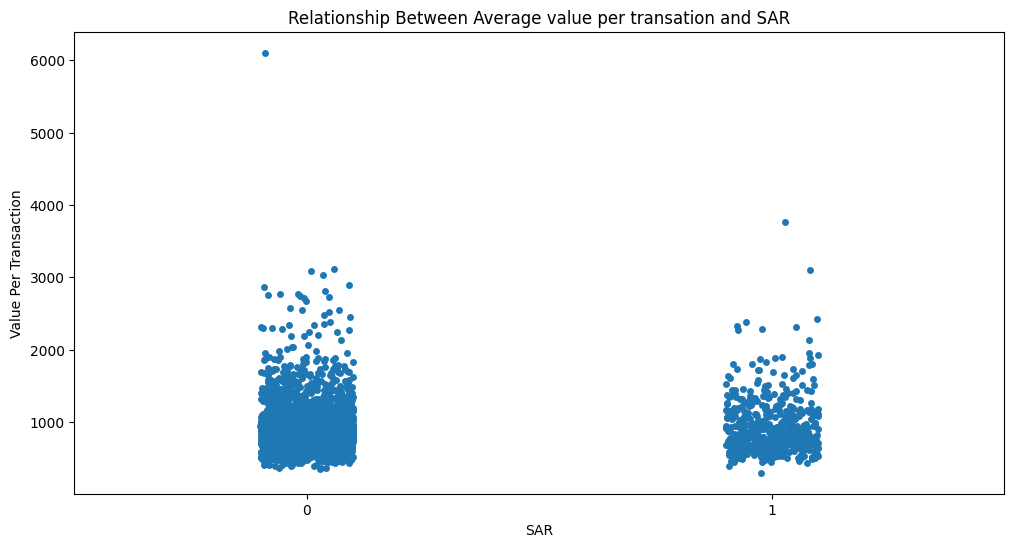

In [368]:
plt.figure(figsize=(12, 6))
sns.stripplot(x='SAR', y='Average_Value_Per_Transaction', data=trusted_data, jitter=True)
plt.title('Relationship Between Average value per transation and SAR')
plt.xlabel('SAR')
plt.ylabel('Value Per Transaction')
plt.show()


### Feature Engineering

#### Dropping columns without any significance.

In [369]:
trusted_data = trusted_data.drop(columns=["Month", "Customer_ID"])

#### Onehot Encoding Transaction_Type

In [370]:
trusted_data['Transaction_Type'].value_counts()

,count
Transaction_Type,
Wire,2795
International,2
Cash,1


In [371]:
trusted_data = pd.get_dummies(trusted_data, columns=['Transaction_Type'], prefix='Transaction')

#### Categorizing Age

In [372]:
# Define age bins and labels
bins = [0, 25, 45, 65, 100]
labels = ['young', 'lower_middle', 'upper_middle', 'old']

trusted_data['Age_Group'] = pd.cut(trusted_data['Age'], bins=bins, labels=labels, right=False)

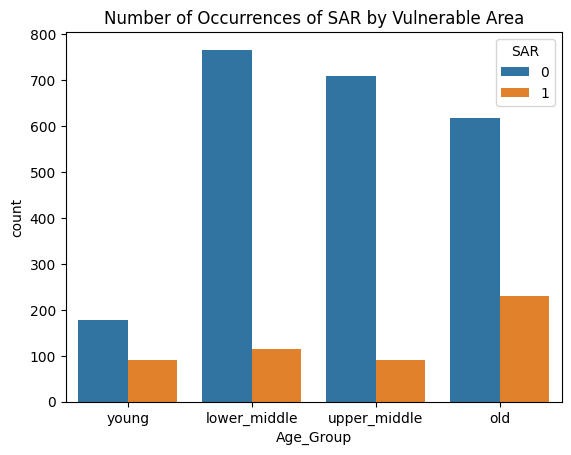

In [373]:
sns.countplot(x='Age_Group', hue='SAR', data=trusted_data)
plt.title('Number of Occurrences of SAR by Vulnerable Area')
plt.show()

In [374]:
# Perform one-hot encoding on the Transaction_Type column
trusted_data = pd.get_dummies(trusted_data, columns=['Age_Group'], prefix='Age_Is')

#### Converting all Boolean to 1 and 0

In [375]:
# Convert all boolean values in the DataFrame to integers (1 for True, 0 for False)
trusted_data = trusted_data.applymap(lambda x: int(x) if isinstance(x, bool) else x)

<ipython-input-375-7ea4488932f9>:2: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  trusted_data = trusted_data.applymap(lambda x: int(x) if isinstance(x, bool) else x)


In [376]:
label_encoder = LabelEncoder()

trusted_data['Sex'] = label_encoder.fit_transform(trusted_data['Sex'])

In [377]:
trusted_data.to_csv("pretrain_trusted.csv", index=False)

#### Corelation between features (And with SAR)

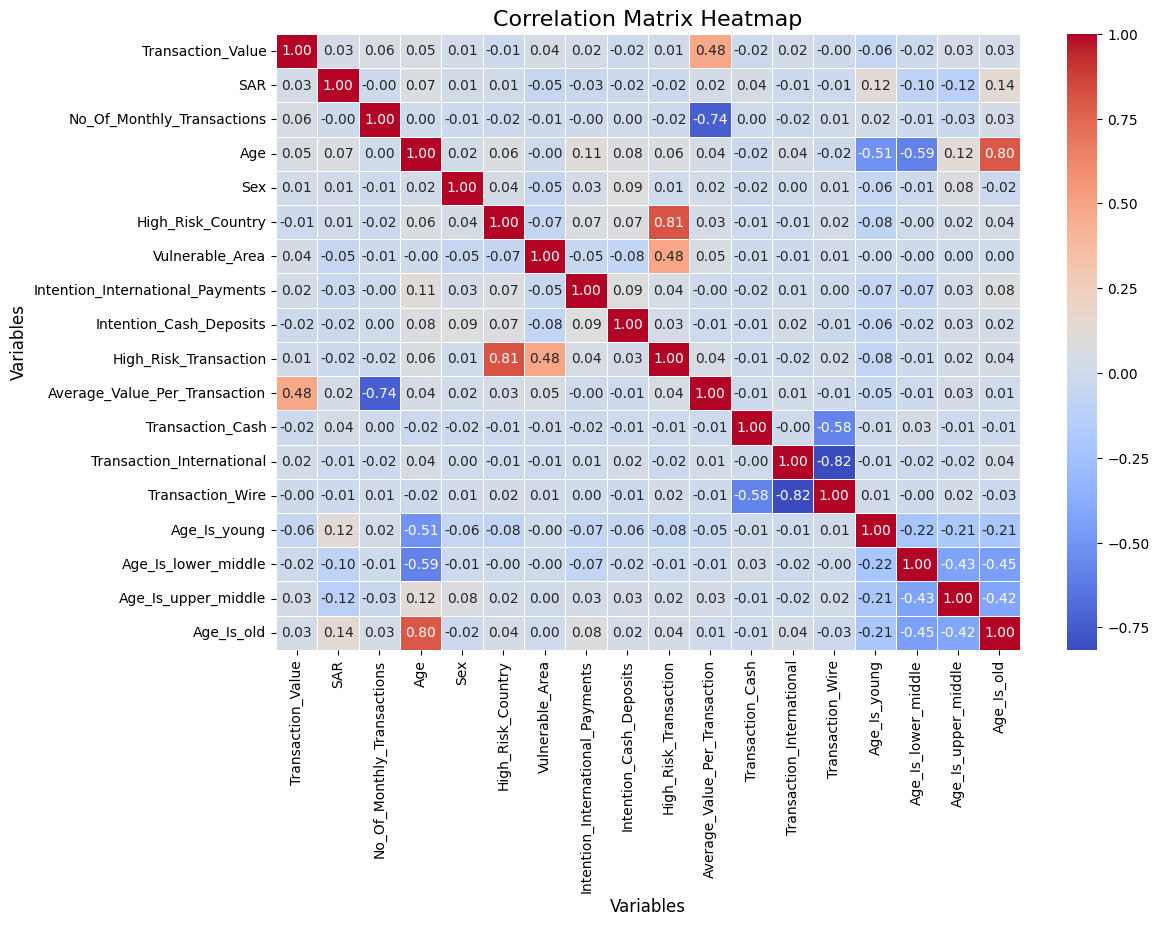

In [378]:
plt.figure(figsize=(12, 8))
sns.heatmap(trusted_data.corr(), annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)


plt.title("Correlation Matrix Heatmap", fontsize=16)
plt.xlabel("Variables", fontsize=12)
plt.ylabel("Variables", fontsize=12)


plt.show()


### Training a Model

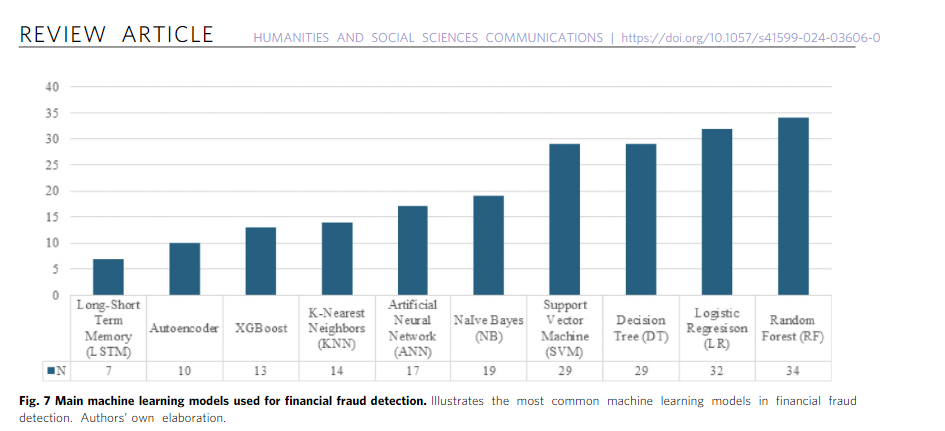

#### RandomForest Classifier

In [379]:


# Define features and target variable
X = trusted_data.drop(columns=['SAR'])  # Features
y = trusted_data['SAR']  # Target

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Initialize the Random Forest classifier
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model
rf_classifier.fit(X_train, y_train)

# Make predictions
y_pred = rf_classifier.predict(X_test)
y_pred_proba = rf_classifier.predict_proba(X_test)[:, 1]

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)
classification_rep = classification_report(y_test, y_pred)

# Print evaluation metrics
print(f"Accuracy: {accuracy:.2f}")
print(f"ROC-AUC Score: {roc_auc:.2f}")
print("Classification Report:")
print(classification_rep)


Accuracy: 0.80
ROC-AUC Score: 0.65
Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.94      0.88       455
           1       0.41      0.18      0.25       105

    accuracy                           0.80       560
   macro avg       0.62      0.56      0.57       560
weighted avg       0.75      0.80      0.76       560



#### Oversampling

In [380]:
# Define features and target variable
X = trusted_data.drop(columns=['SAR'])  # Features
y = trusted_data['SAR']  # Target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Apply SMOTE to the training set
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("Before SMOTE:")
print("Class distribution:", y_train.value_counts())

print("After SMOTE:")
print("Class distribution:", y_train_resampled.value_counts())

# Initialize the Random Forest classifier
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model
rf_classifier.fit(X_train_resampled, y_train_resampled)

# Make predictions
y_pred = rf_classifier.predict(X_test)
y_pred_proba = rf_classifier.predict_proba(X_test)[:, 1]

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)
classification_rep = classification_report(y_test, y_pred)

# Print evaluation metrics
print(f"Accuracy: {accuracy:.2f}")
print(f"ROC-AUC Score: {roc_auc:.2f}")
print("Classification Report:")
print(classification_rep)



Before SMOTE:
Class distribution: SAR
0    1828
1     410
Name: count, dtype: int64
After SMOTE:
Class distribution: SAR
0    1828
1    1828
Name: count, dtype: int64


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/utils/_tags.py:354: FutureWarning: The SMOTE or classes from which it inherits use `_get_tags` and `_more_tags`. Please define the `__sklearn_tags__` method, or inherit from `sklearn.base.BaseEstimator` and/or other appropriate mixins such as `sklearn.base.TransformerMixin`, `sklearn.base.ClassifierMixin`, `sklearn.base.RegressorMixin`, and `sklearn.base.OutlierMixin`. From scikit-learn 1.7, not defining `__sklearn_tags__` will raise an error.
  warnings.warn(


Accuracy: 0.76
ROC-AUC Score: 0.60
Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.90      0.85       445
           1       0.34      0.20      0.25       115

    accuracy                           0.76       560
   macro avg       0.58      0.55      0.55       560
weighted avg       0.72      0.76      0.73       560



#### Tuning HyperParameters

In [381]:


# Define features and target variable
X = trusted_data.drop(columns=['SAR'])  # Features
y = trusted_data['SAR']  # Target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Apply SMOTE to the training set
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

grid_search = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=3, scoring='recall')
grid_search.fit(X_train_resampled, y_train_resampled)

best_rf = grid_search.best_estimator_
y_pred = best_rf.predict(X_test)

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/utils/_tags.py:354: FutureWarning: The SMOTE or classes from which it inherits use `_get_tags` and `_more_tags`. Please define the `__sklearn_tags__` method, or inherit from `sklearn.base.BaseEstimator` and/or other appropriate mixins such as `sklearn.base.TransformerMixin`, `sklearn.base.ClassifierMixin`, `sklearn.base.RegressorMixin`, and `sklearn.base.OutlierMixin`. From scikit-learn 1.7, not defining `__sklearn_tags__` will raise an error.
  warnings.warn(


              precision    recall  f1-score   support

           0       0.81      0.89      0.85       445
           1       0.31      0.19      0.24       115

    accuracy                           0.75       560
   macro avg       0.56      0.54      0.54       560
weighted avg       0.71      0.75      0.72       560



## Untrusted Data for Unsuperivsed Learning Model

### Feature Engineering

#### Adding High Risk Transaction Column

In [382]:
untrusted_data['High_Risk_Transaction'] = (untrusted_data['High_Risk_Country'] | untrusted_data['Vulnerable_Area'])

<ipython-input-382-5ff69f1560f3>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  untrusted_data['High_Risk_Transaction'] = (untrusted_data['High_Risk_Country'] | untrusted_data['Vulnerable_Area'])


#### Adding Average Value Per Transaction

In [383]:
untrusted_data['Average_Value_Per_Transaction'] = untrusted_data['Transaction_Value'] / untrusted_data['No_Of_Monthly_Transactions']

<ipython-input-383-3663c112b97a>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  untrusted_data['Average_Value_Per_Transaction'] = untrusted_data['Transaction_Value'] / untrusted_data['No_Of_Monthly_Transactions']


#### Transaction type one hot encoded

In [384]:
untrusted_data = pd.get_dummies(untrusted_data, columns=['Transaction_Type'], prefix='Transaction')

#### Categorizing age

In [385]:
bins = [0, 25, 45, 65, 100]
labels = ['young', 'lower_middle', 'upper_middle', 'old']


untrusted_data['Age_Group'] = pd.cut(untrusted_data['Age'], bins=bins, labels=labels, right=False)


In [386]:
untrusted_data = pd.get_dummies(untrusted_data, columns=['Age_Group'], prefix='Age_Is')

#### Dropping the columns

In [387]:
untrusted_data = untrusted_data.drop(columns=['Customer_ID', 'Month', 'SAR'])

In [388]:
untrusted_data['Sex'] = untrusted_data['Sex'].map({'Male': 1, 'Female': 0})

boolean_columns = ['High_Risk_Country', 'Vulnerable_Area', 'Intention_International_Payments',
                   'Intention_Cash_Deposits', 'High_Risk_Transaction', 'Transaction_Cash',
                   'Transaction_Wire', 'Age_Is_young', 'Age_Is_lower_middle',
                   'Age_Is_upper_middle', 'Age_Is_old']
for col in boolean_columns:
    untrusted_data[col] = untrusted_data[col].astype(int)

In [389]:
untrusted_data.to_csv("pretrain_untrusted.csv", index=False)

### Training a model

In [390]:
features = untrusted_data[
    [
        "Transaction_Value",
        "No_Of_Monthly_Transactions",
        "Age",
        "High_Risk_Country",
        "Vulnerable_Area",
        "Intention_International_Payments",
        "Intention_Cash_Deposits",
        "High_Risk_Transaction",
        "Average_Value_Per_Transaction",
        "Transaction_Cash",
        "Transaction_Wire",
        "Age_Is_young",
        "Age_Is_lower_middle",
        "Age_Is_upper_middle",
        "Age_Is_old",
    ]
]

features["Age_Is_old"] *= 10


scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)


isolation_forest = IsolationForest(random_state=42, contamination=0.1)
anomaly_labels = isolation_forest.fit_predict(scaled_features)


anomaly_labels = [1 if label == -1 else 0 for label in anomaly_labels]


untrusted_data["Anomaly"] = anomaly_labels


untrusted_data.to_csv("anomaly_detected_data.csv", index=False)

<ipython-input-390-3e769f150b93>:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  features["Age_Is_old"] *= 10


In [391]:
untrusted_data['Anomaly'].value_counts()

,count
Anomaly,
0,8281
1,921


In [392]:
untrusted_data.rename(columns={"Anomaly": "SAR"}, inplace=True)

## Merging both Trusted and Untrusted Data

In [393]:
concatenated_df = pd.concat([trusted_data, untrusted_data], ignore_index=True)
concatenated_df.shape

(12000, 18)

In [394]:
# Define features and target variable
X = concatenated_df.drop(columns=['SAR'])  # Features
y = concatenated_df['SAR']  # Target

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Initialize the Random Forest classifier
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model
rf_classifier.fit(X_train, y_train)

# Make predictions
y_pred = rf_classifier.predict(X_test)
y_pred_proba = rf_classifier.predict_proba(X_test)[:, 1]

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)
classification_rep = classification_report(y_test, y_pred)

# Print evaluation metrics
print(f"Accuracy: {accuracy:.2f}")
print(f"ROC-AUC Score: {roc_auc:.2f}")
print("Classification Report:")
print(classification_rep)


Accuracy: 0.94
ROC-AUC Score: 0.96
Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.98      0.97      2111
           1       0.84      0.63      0.72       289

    accuracy                           0.94      2400
   macro avg       0.89      0.81      0.84      2400
weighted avg       0.94      0.94      0.94      2400

